# Ablation studies on `elitist_as_root` period

Problem: `cvrp_pomo`

Algorithm: `oragent`

Data:
- `ablation_studies_on_elitist_as_root_period_data/bpp_online_elitist_as_root_period=2/`
- `ablation_studies_on_elitist_as_root_period_data/bpp_online_elitist_as_root_period=4/`
- `ablation_studies_on_elitist_as_root_period_data/bpp_online_elitist_as_root_period=8/`
- `ablation_studies_on_elitist_as_root_period_data/bpp_online_elitist_as_root_period=16/`
- `ablation_studies_on_elitist_as_root_period_data/bpp_online_elitist_as_root_period=32/`
- `ablation_studies_on_elitist_as_root_period_data/cvrp_pomo_elitist_as_root_period=2/`
- `ablation_studies_on_elitist_as_root_period_data/cvrp_pomo_elitist_as_root_period=4/`
- `ablation_studies_on_elitist_as_root_period_data/cvrp_pomo_elitist_as_root_period=8/`
- `ablation_studies_on_elitist_as_root_period_data/cvrp_pomo_elitist_as_root_period=16/`
- `ablation_studies_on_elitist_as_root_period_data/cvrp_pomo_elitist_as_root_period=32/`


In [88]:
# Load data from output dir
from pathlib import Path
import json

current_dir = Path().resolve()
project_root = current_dir.parent

# TODO: set algorithms and problems to analysis
algorithm = 'or_agent'
problems = ('cvrp_pomo', 'bpp_online')
choices = (2, 4, 8, 16, 32)

# read results.json and store in `results` dict
results = {}
for problem in problems:
    for choice in choices:
        filepath = f"{project_root}/research_results/ablation_studies_on_elitist_as_root_period_data/{problem}_elitist_as_root_period={choice}/results.json"
        with open(filepath, "r") as fp:
            results[(problem, choice)] = json.load(fp)

for k, v in results.items():
    print(f"=====(problem, period): {k}=====")
    for entry in v:
        print(entry)

=====(problem, period): ('cvrp_pomo', 2)=====
{'iteration': 0, 'total_responses': 0, 'total_function_evals': 1, 'total_valid_responses': 0, 'best_obj_overall': 73.3245849609375, 'metrics': {'200': 22.36349868774414, '500': 50.416988372802734, '1000': 147.19326782226562}, 'code_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_elitist_as_period_2/details/lead1_round0_count0_id0_solution.py', 'output_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_elitist_as_period_2/details/lead1_round0_count0_id0_stdout.txt'}
{'iteration': 0, 'total_responses': 27, 'total_function_evals': 27, 'total_valid_responses': 21, 'best_obj_overall': 70.9813404083252, 'metrics': {'200': 22.47508430480957, '500': 51.58340835571289, '1000': 138.88552856445312}, 'code_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_elitist_as_period_2/details/lead1_round0_count12_id12_solution.py', 'output_filepath': 'outputs/oragent/cvrp_pomo/standard_mode14_elitist_as_period_2/details/lead1_round0_count12_id12_std

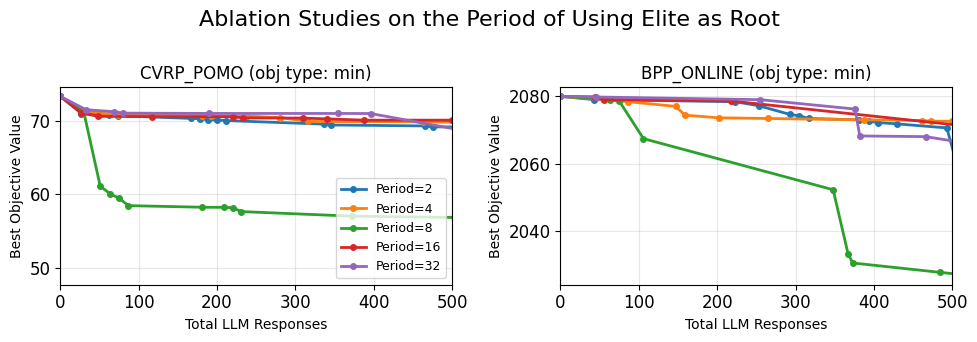

In [89]:
import matplotlib.pyplot as plt
from plotlib import color_scheme, font_scheme


performance_index = 'total_responses'
x_label = 'Total LLM Responses'

curve_label = {
    2: 'Period=2',
    4: 'Period=4',
    8: 'Period=8',
    16: 'Period=16',
    32: 'Period=32',
}


# manually set the x-lim
min_x = 0
max_x = 500

# =====Handle data=====
# Add last entry for `results.json`
# the last elitist at x_lim may be missing since results.json is only updated when a new elitist solution is found; we need to manually add the last elitist for plotting
# PS: later we added another logging file - `results_detailed.json` - that record elitist for every iteration (repetitions allowed)
from copy import deepcopy

if True:
    for problem in problems:
        for choice in choices:
            last_entry = deepcopy(results[(problem, choice)][-1])
            if last_entry[performance_index] < max_x:
                last_entry[performance_index] = max_x
                results[(problem, choice)].append(last_entry)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes = axes.flatten()

# Problem titles for each subplot
problem_titles = {
    'cvrp_pomo': 'CVRP_POMO (obj type: min)',
    'bpp_online': 'BPP_ONLINE (obj type: min)',
}

# Plot each problem in its own subplot
for idx, problem in enumerate(problems):
    ax = axes[idx]
    
    # Plot each algorithm
    for t in choices:
        # Extract total_responses and best_obj_overall
        total_responses = [entry[performance_index] for entry in results[(problem, t)]]
        best_obj_overall = [entry['best_obj_overall'] for entry in results[(problem, t)]]
        
        # Plot the curve
        ax.plot(total_responses, best_obj_overall, marker='o', markersize=4, label=curve_label[t], linewidth=2)
        
        ax.set_xlim(min_x, max_x)
        ax.set_xlabel(x_label, fontsize=10)
        ax.set_ylabel('Best Objective Value', fontsize=10)
        ax.set_title(f'{problem_titles[problem]}', fontsize=12)
        ax.grid(True, alpha=0.3)

    # Add legend only to first subplot
    if idx == 0:
        ax.legend(fontsize=9)


fig.suptitle('Ablation Studies on the Period of Using Elite as Root', fontsize=16, y=0.98)

# Adjust layout
plt.tight_layout()
plt.savefig('ablation_elite_as_root_period.png', dpi=300, bbox_inches='tight')
plt.show()
